In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from category_encoders import BinaryEncoder

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

In [2]:
df_raw = pd.read_csv("../data/credit_card_frauds.csv")

**División de los datos**

Dividimos los datos nada mas empezar para que no se produzca data leakage.

In [3]:
X = df_raw.drop('is_fraud', axis=1)
y = df_raw['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

df = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)



In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 271685 entries, 179685 to 109523
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  271685 non-null  str    
 1   merchant               271685 non-null  str    
 2   category               271685 non-null  str    
 3   amt                    271685 non-null  float64
 4   city                   271685 non-null  str    
 5   state                  271685 non-null  str    
 6   lat                    271685 non-null  float64
 7   long                   271685 non-null  float64
 8   city_pop               271685 non-null  int64  
 9   job                    271685 non-null  str    
 10  dob                    271685 non-null  str    
 11  trans_num              271685 non-null  str    
 12  merch_lat              271685 non-null  float64
 13  merch_long             271685 non-null  float64
 14  is_fraud               271685 non-null  int64  

In [5]:
#Convertimos en fehca las variables 'trans_Date_trans_time' y 'dob'

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

df_test['trans_date_trans_time'] = pd.to_datetime(df_test['trans_date_trans_time'])
df_test['dob'] = pd.to_datetime(df_test['dob'])

In [6]:
df.shape

(271685, 15)

In [7]:
df_test.shape

(67922, 15)

In [8]:
print(f"% Train: {df.shape[0]/df_raw.shape[0]} , % Test: {df_test.shape[0]/df_raw.shape[0]}")

% Train: 0.7999982332519647 , % Test: 0.20000176674803524


In [9]:
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
179685,2020-02-01 13:21:27,"Streich, Rolfson and Wilderman",kids_pets,24.79,Hooper,NE,41.6414,-96.5232,1745,"Engineer, automotive",1973-12-26,e77c97ca17e3fbc26a50613965b1535d,40.751034,-97.116876,0
138301,2019-11-17 21:27:54,Wilkinson Lt,entertainment,12.40,Hooper,NE,41.6414,-96.5232,1745,"Engineer, automotive",1973-12-26,e386b85fb56052f4a56624aadb7d20fd,41.826237,-97.070998,0
200559,2020-03-30 10:30:24,"Moen, Reinger and Murphy",grocery_pos,108.34,Hatch,UT,37.7175,-112.4777,258,Geoscientist,1961-11-24,df5605c760137917772ebc3d00e302de,37.830209,-112.288001,0
39697,2019-04-20 06:20:42,"Greenfelder, Bartoletti and Davis",misc_net,179.56,Indian Wells,CA,33.7163,-116.3381,4677,Learning mentor,1955-05-06,c536e8ae3366dac06d573fb330032871,32.849351,-116.551486,0
84427,2019-07-22 05:34:32,"Ruecker, Beer and Collie",shopping_net,9.17,Carlotta,CA,40.5070,-123.9743,1139,"Therapist, occupational",1951-01-15,23f46db383c0b293201808909fe6458a,40.492905,-124.469651,0


In [10]:
df.describe(percentiles=[.25,.5,.75,.9,.95,.99]).T

,count,mean,min,25%,50%,75%,90%,95%,99%,max,std
trans_date_trans_time,271685,2020-01-20 20:37:11.430281,2019-01-01 00:00:44,2019-07-23 06:15:49,2020-01-01 02:41:14,2020-07-23 12:25:26,2020-11-13 11:07:38.800000,2020-12-11 20:29:17,2020-12-28 00:28:57.840000,2020-12-31 23:59:24,NaN
amt,271685.0,70.715613,1.0,9.61,46.59,83.37,139.56,199.318,548.728,16837.08,158.413544
lat,271685.0,39.722564,20.0271,36.7154,39.6171,41.71,45.671,47.4974,48.8878,66.6933,5.100956
long,271685.0,-110.62104,-165.6723,-120.0936,-111.0292,-100.6215,-93.6289,-91.8912,-90.387,-89.6287,12.669305
city_pop,271685.0,107504.690115,46.0,493.0,1661.0,35705.0,320420.0,841711.0,1312922.0,2383912.0,293661.410436
dob,271685,1972-03-27 02:08:59.221524,1927-09-09 00:00:00,1961-10-24 00:00:00,1974-03-10 00:00:00,1985-08-21 00:00:00,1990-01-17 00:00:00,1995-04-19 00:00:00,2000-08-16 00:00:00,2001-07-26 00:00:00,NaN
merch_lat,271685.0,39.722237,19.027785,36.820109,39.590181,42.193976,45.778557,47.683802,49.704726,67.510267,5.136503
merch_long,271685.0,-110.62048,-166.671575,-119.835779,-111.031084,-100.31824,-93.494307,-91.885283,-89.962797,-88.629203,12.683059
is_fraud,271685.0,0.005249,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.072258


In [11]:
df.isnull().sum()

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Eliminamos el numero de transferencia ('trans_num') ya que es un identificador único, y no va a aportar nada al modelo


In [12]:
df =df.copy()

In [13]:
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
df_test['age'] = (df_test['trans_date_trans_time'] - df_test['dob']).dt.days // 365

# 3. Extraer información temporal de la transacción
# La hora es vital para detectar fraudes nocturnos
df['hour'] = df['trans_date_trans_time'].dt.hour
df_test['hour'] = df_test['trans_date_trans_time'].dt.hour

# El día de la semana (0=Lunes, 6=Domingo)
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month
df['is_weekend'] = df['trans_date_trans_time'].dt.dayofweek.isin([5,6]).astype(int)

df_test['day_of_week'] = df_test['trans_date_trans_time'].dt.dayofweek
df_test['month'] = df_test['trans_date_trans_time'].dt.month
df_test['is_weekend'] = df_test['trans_date_trans_time'].dt.dayofweek.isin([5,6]).astype(int)

In [14]:
df.drop(columns='trans_num',inplace=True)
df_test.drop(columns='trans_num',inplace=True)

In [15]:
#Porcentaje de fraude (0=No fraude , 1=Fraude) respecto al total
df['is_fraud'].value_counts(normalize=True)*100

is_fraud
0    99.475127
1     0.524873
Name: proportion, dtype: float64

Observamos que nuestra target tiene un desequilibrio entre los fraudes y no fraudes. Cosa que tendremos que tener en cuenta a la hora de hacer la división de datasets de train y de test.

In [16]:
numeric_cols = df.select_dtypes(exclude='object').columns.tolist()
categoric_cols = df.select_dtypes(include=['object','bool']).columns.tolist()

C:\Users\Administrador\AppData\Local\Temp\ipykernel_11444\3647814662.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoric_cols = df.select_dtypes(include=['object','bool']).columns.tolist()


In [17]:
numeric_cols

['trans_date_trans_time',
 'amt',
 'lat',
 'long',
 'city_pop',
 'dob',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'age',
 'hour',
 'day_of_week',
 'month',
 'is_weekend']

In [18]:
categoric_cols

['merchant', 'category', 'city', 'state', 'job']

## Análisis Univariable y Preprocessing

**Variables Categóricas**

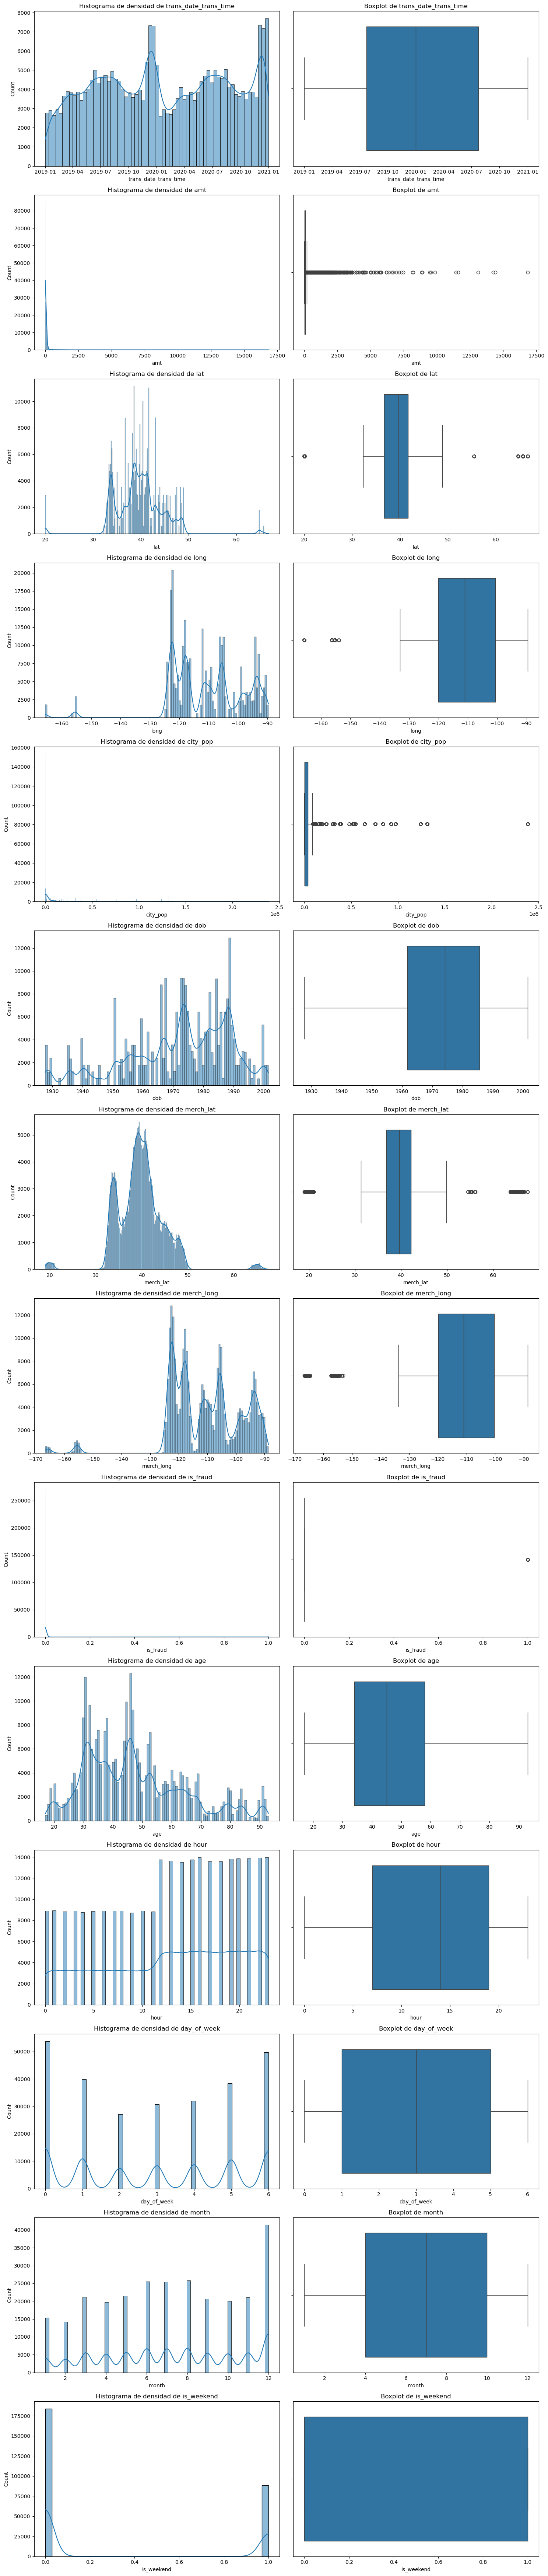

In [19]:
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(15, 5 * len(numeric_cols)))

for i, column in enumerate(df[numeric_cols]):
    # Histograma de densidad
    sns.histplot(df[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

Ver el número de registros y de porcentaje de outliers hay.

In [20]:
print("--- Resumen de Outliers ---")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    perc = (len(outliers) / len(df)) * 100
    print(f"{col}: {len(outliers)} registros ({perc:.2f}%)")

--- Resumen de Outliers ---
trans_date_trans_time: 0 registros (0.00%)
amt: 14532 registros (5.35%)
lat: 5316 registros (1.96%)
long: 5306 registros (1.95%)
city_pop: 52188 registros (19.21%)
dob: 0 registros (0.00%)
merch_lat: 5316 registros (1.96%)
merch_long: 5306 registros (1.95%)
is_fraud: 1426 registros (0.52%)
age: 0 registros (0.00%)
hour: 0 registros (0.00%)
day_of_week: 0 registros (0.00%)
month: 0 registros (0.00%)
is_weekend: 0 registros (0.00%)


**Tratamiento de los outliers**

Hemos detectado que hay outliers en los siguientes campos: 'amt' ,'lat', 'long', city_pop', 'merch_lat', 'merch_long'. El tratamiento que le vamos a realizar es el siguiente:
1. 'amt' y 'city_pop', al tener muchísimos outliers, vamos a implementar un logaritmo para normalizar la distribución.
2. Para las variables geográficas 'lat', 'long', 'merch_lat' y 'merch_long', la estrategia que vamos a implementar es un RobustScaler. Como no queremos borrar los outliers, este método compensa su impacto escalando los datos mediante la mediana y el rango intercuartílico, evitando que los puntos más lejanos deformen el resto de la distribución.

In [21]:
amt_pop_cols = ['amt','city_pop']
df_amt_pop = df.copy()

for c in amt_pop_cols:
    df_amt_pop[c + '_log'] = np.log1p(df_amt_pop[c])

df[amt_pop_cols] = np.log1p(df[amt_pop_cols])


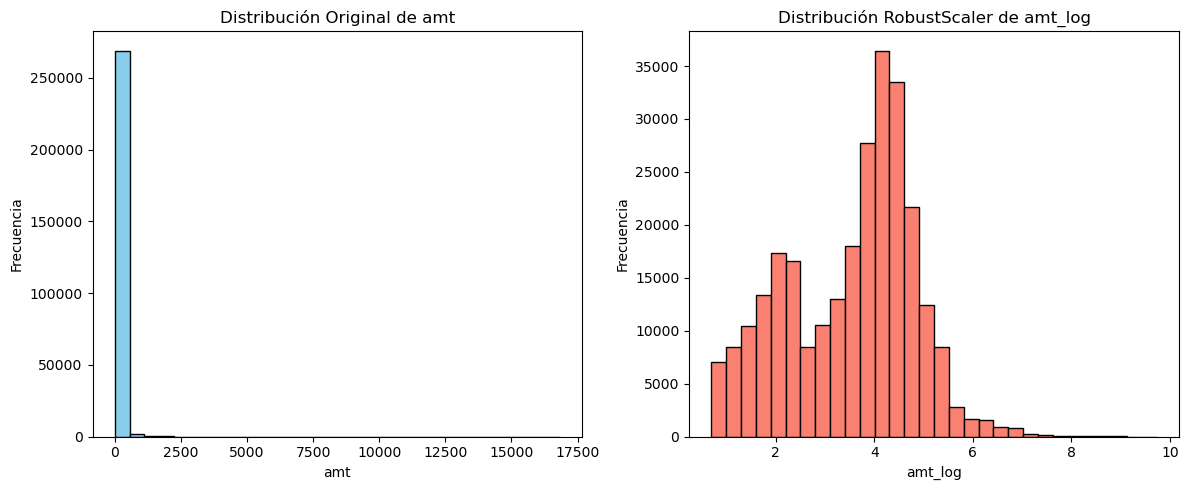

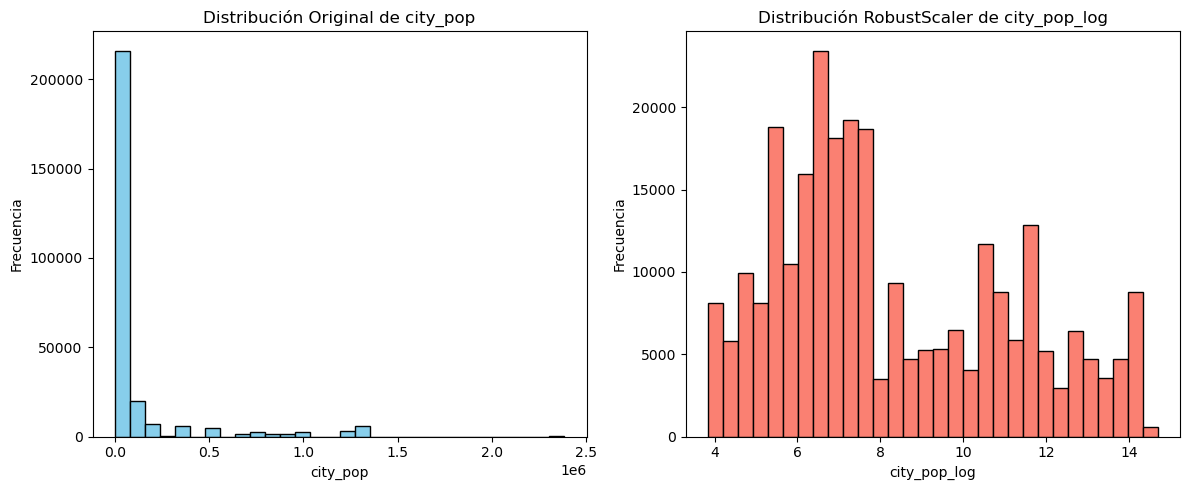

In [22]:
cols_to_plot = [
    ('amt', 'amt_log'),
    ('city_pop', 'city_pop_log'),
]

# Iniciamos el bucle
for col_orig, col_log in cols_to_plot:
    plt.figure(figsize=(12, 5))
    
    # 1. Histograma Original
    plt.subplot(1, 2, 1)
    plt.hist(df_amt_pop[col_orig], bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Distribución Original de {col_orig}")
    plt.xlabel(col_orig)
    plt.ylabel("Frecuencia")
    
    # 2. Histograma Transformado
    plt.subplot(1, 2, 2)
    plt.hist(df_amt_pop[col_log], bins=30, color="salmon", edgecolor="black")
    plt.title(f"Distribución RobustScaler de {col_log}")
    plt.xlabel(col_log)
    plt.ylabel("Frecuencia")
    
    plt.tight_layout()
    plt.show()

Implementamos el Robust Scaler y vemos la normalización.

In [23]:
lat_long_cols = ['lat', 'long', 'merch_lat', 'merch_long']
df_lat_long_cols = df.copy()

scaler = RobustScaler()

# Creamos una lista de nombres nuevos: ['lat_robust', 'long_robust', ...]
new_cols = [c + '_robust' for c in lat_long_cols]

# Asignamos las 4 columnas de salida a los 4 nombres nuevos
df_lat_long_cols[new_cols] = scaler.fit_transform(df_lat_long_cols[lat_long_cols])
df[lat_long_cols] = scaler.fit_transform(df[lat_long_cols])

Vemos la comparación entre las variables Original vs la Robusta

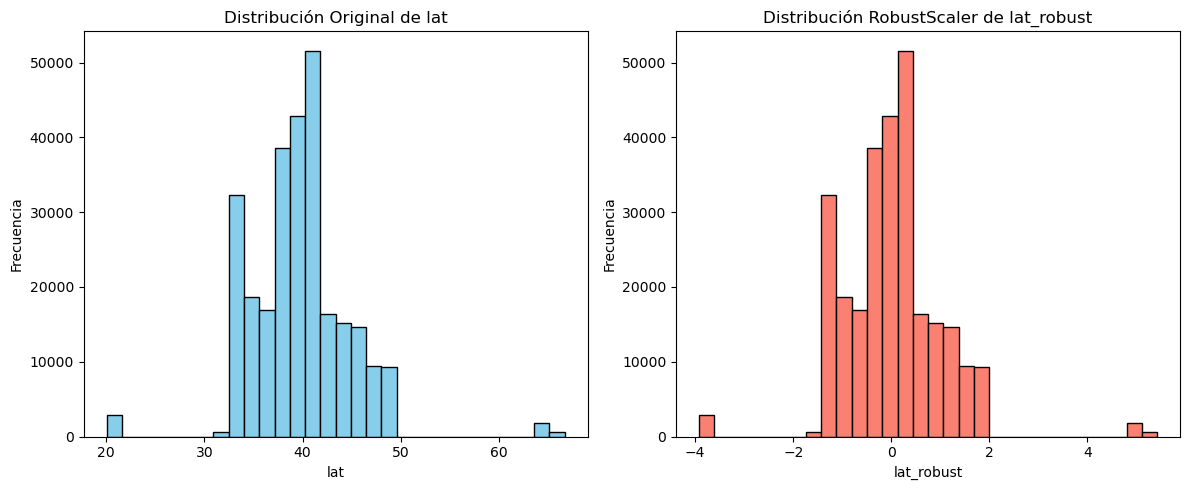

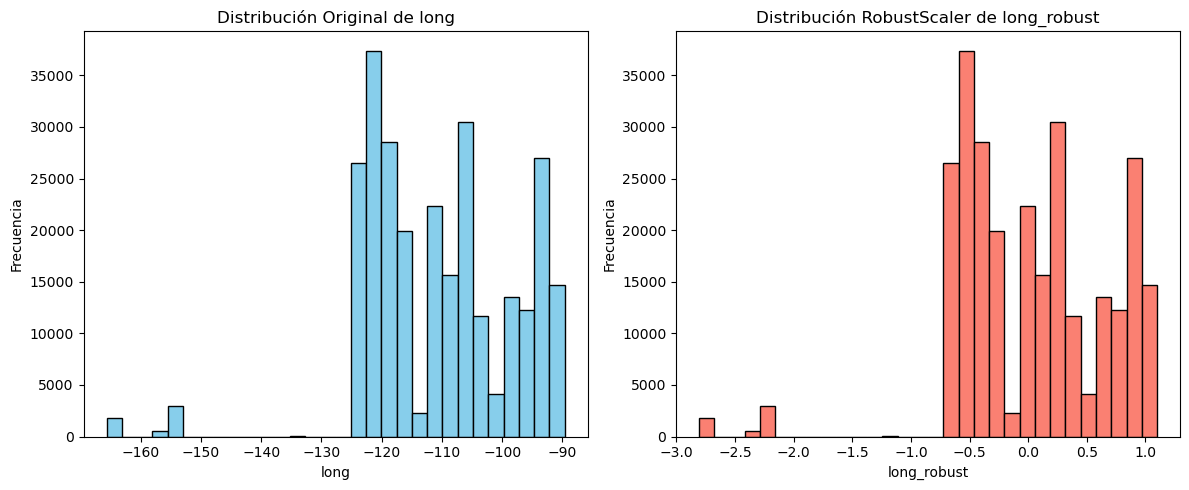

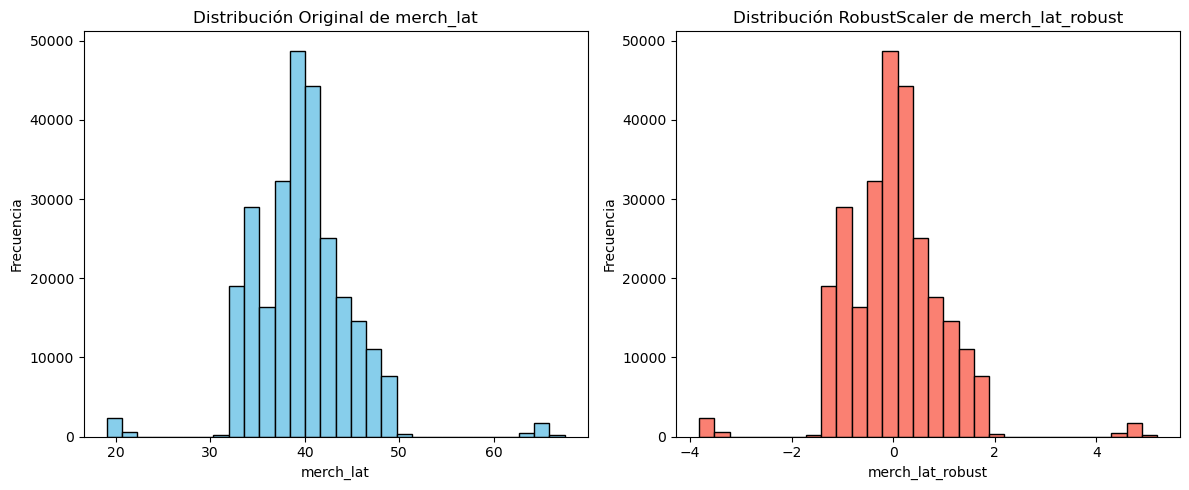

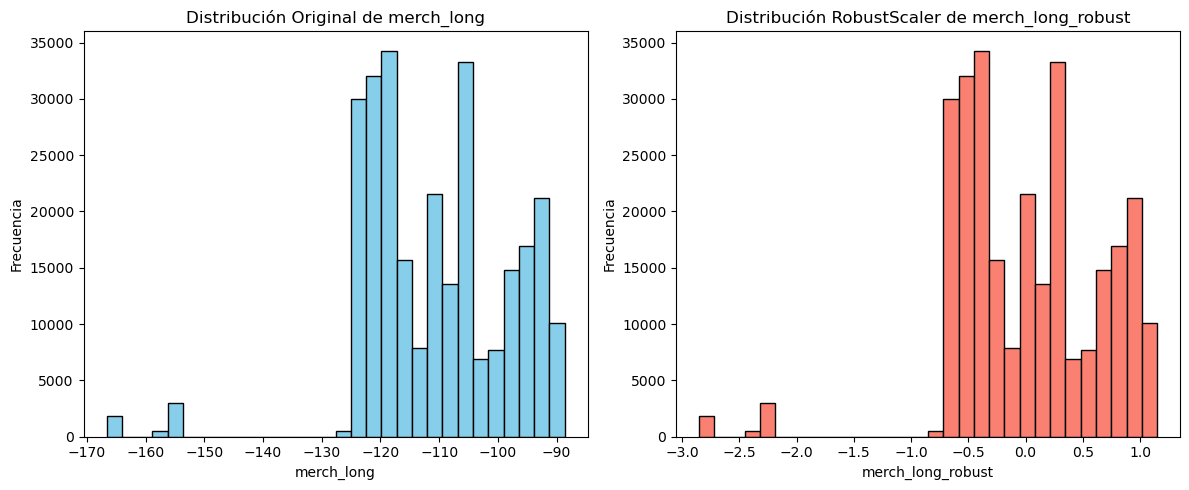

In [24]:
# Definimos las parejas de columnas (Original vs Robusta)
# Asegúrate de haber creado las columnas '_robust' antes
cols_to_plot = [
    ('lat', 'lat_robust'),
    ('long', 'long_robust'),
    ('merch_lat', 'merch_lat_robust'),
    ('merch_long', 'merch_long_robust')
]

# Iniciamos el bucle
for col_orig, col_rob in cols_to_plot:
    plt.figure(figsize=(12, 5))
    
    # 1. Histograma Original
    plt.subplot(1, 2, 1)
    plt.hist(df_lat_long_cols[col_orig], bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Distribución Original de {col_orig}")
    plt.xlabel(col_orig)
    plt.ylabel("Frecuencia")
    
    # 2. Histograma Transformado
    plt.subplot(1, 2, 2)
    plt.hist(df_lat_long_cols[col_rob], bins=30, color="salmon", edgecolor="black")
    plt.title(f"Distribución RobustScaler de {col_rob}")
    plt.xlabel(col_rob)
    plt.ylabel("Frecuencia")
    
    plt.tight_layout()
    plt.show()

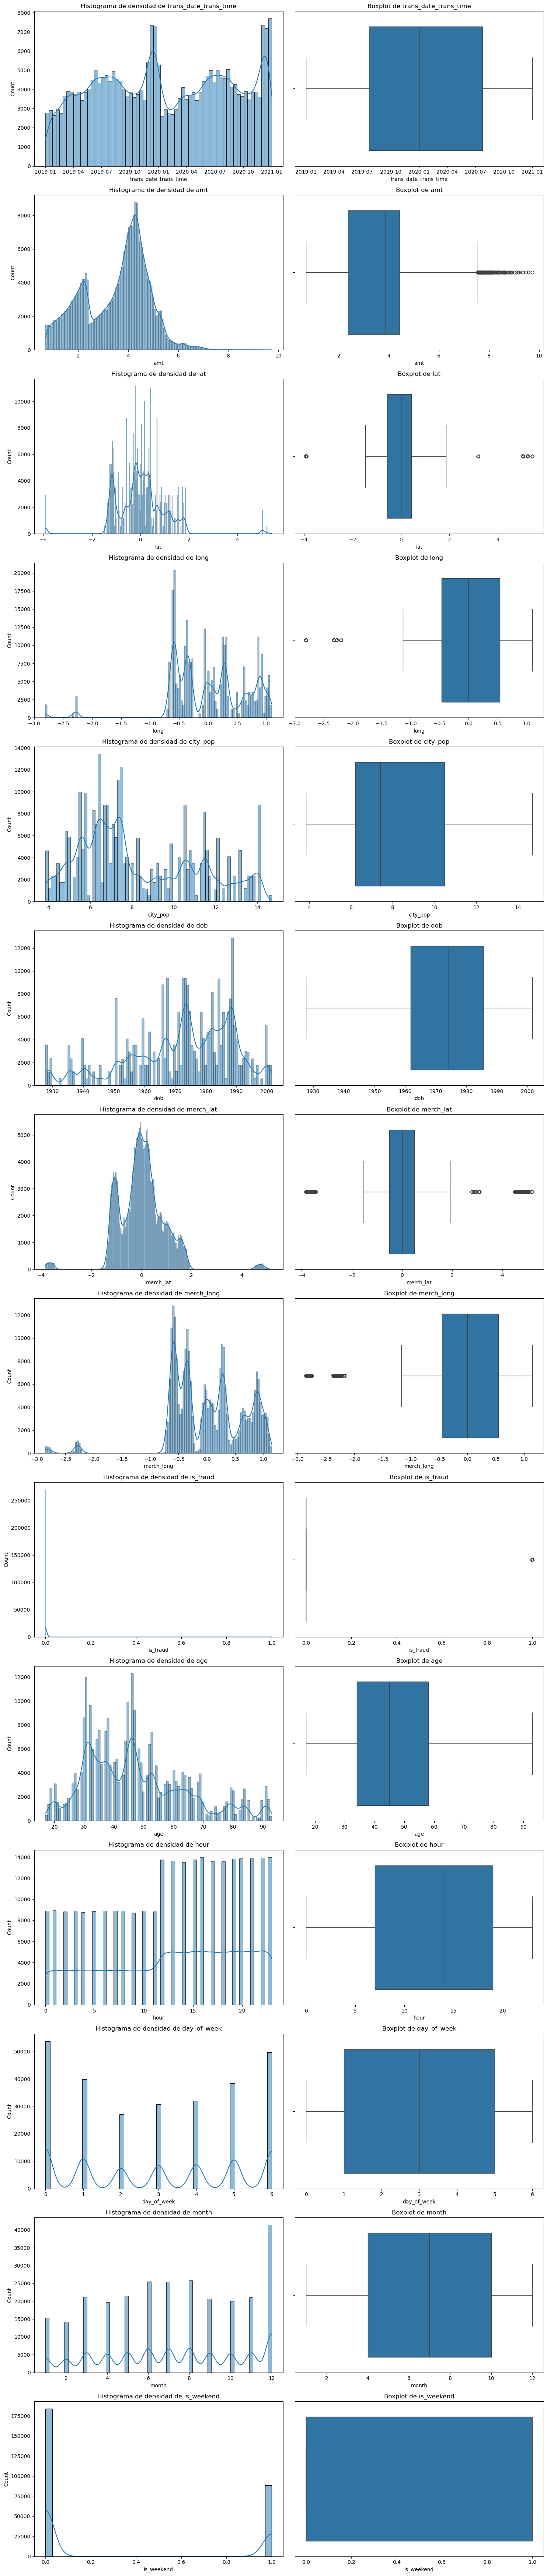

In [25]:
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(15, 5 * len(numeric_cols)))

for i, column in enumerate(df[numeric_cols]):
    # Histograma de densidad
    sns.histplot(df[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

**Columnas Categóricas**

In [26]:
#Creamos un nuevo DataFrame, con el fin de poner la variable target como categórica para la visualización, ya que se trataría de un bool.
df_fraud = df.copy()
df_fraud['is_fraud'] = df_fraud['is_fraud'].map({0: 'Legit', 1: 'Fraud'})

C:\Users\Administrador\AppData\Local\Temp\ipykernel_11444\3184947478.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns


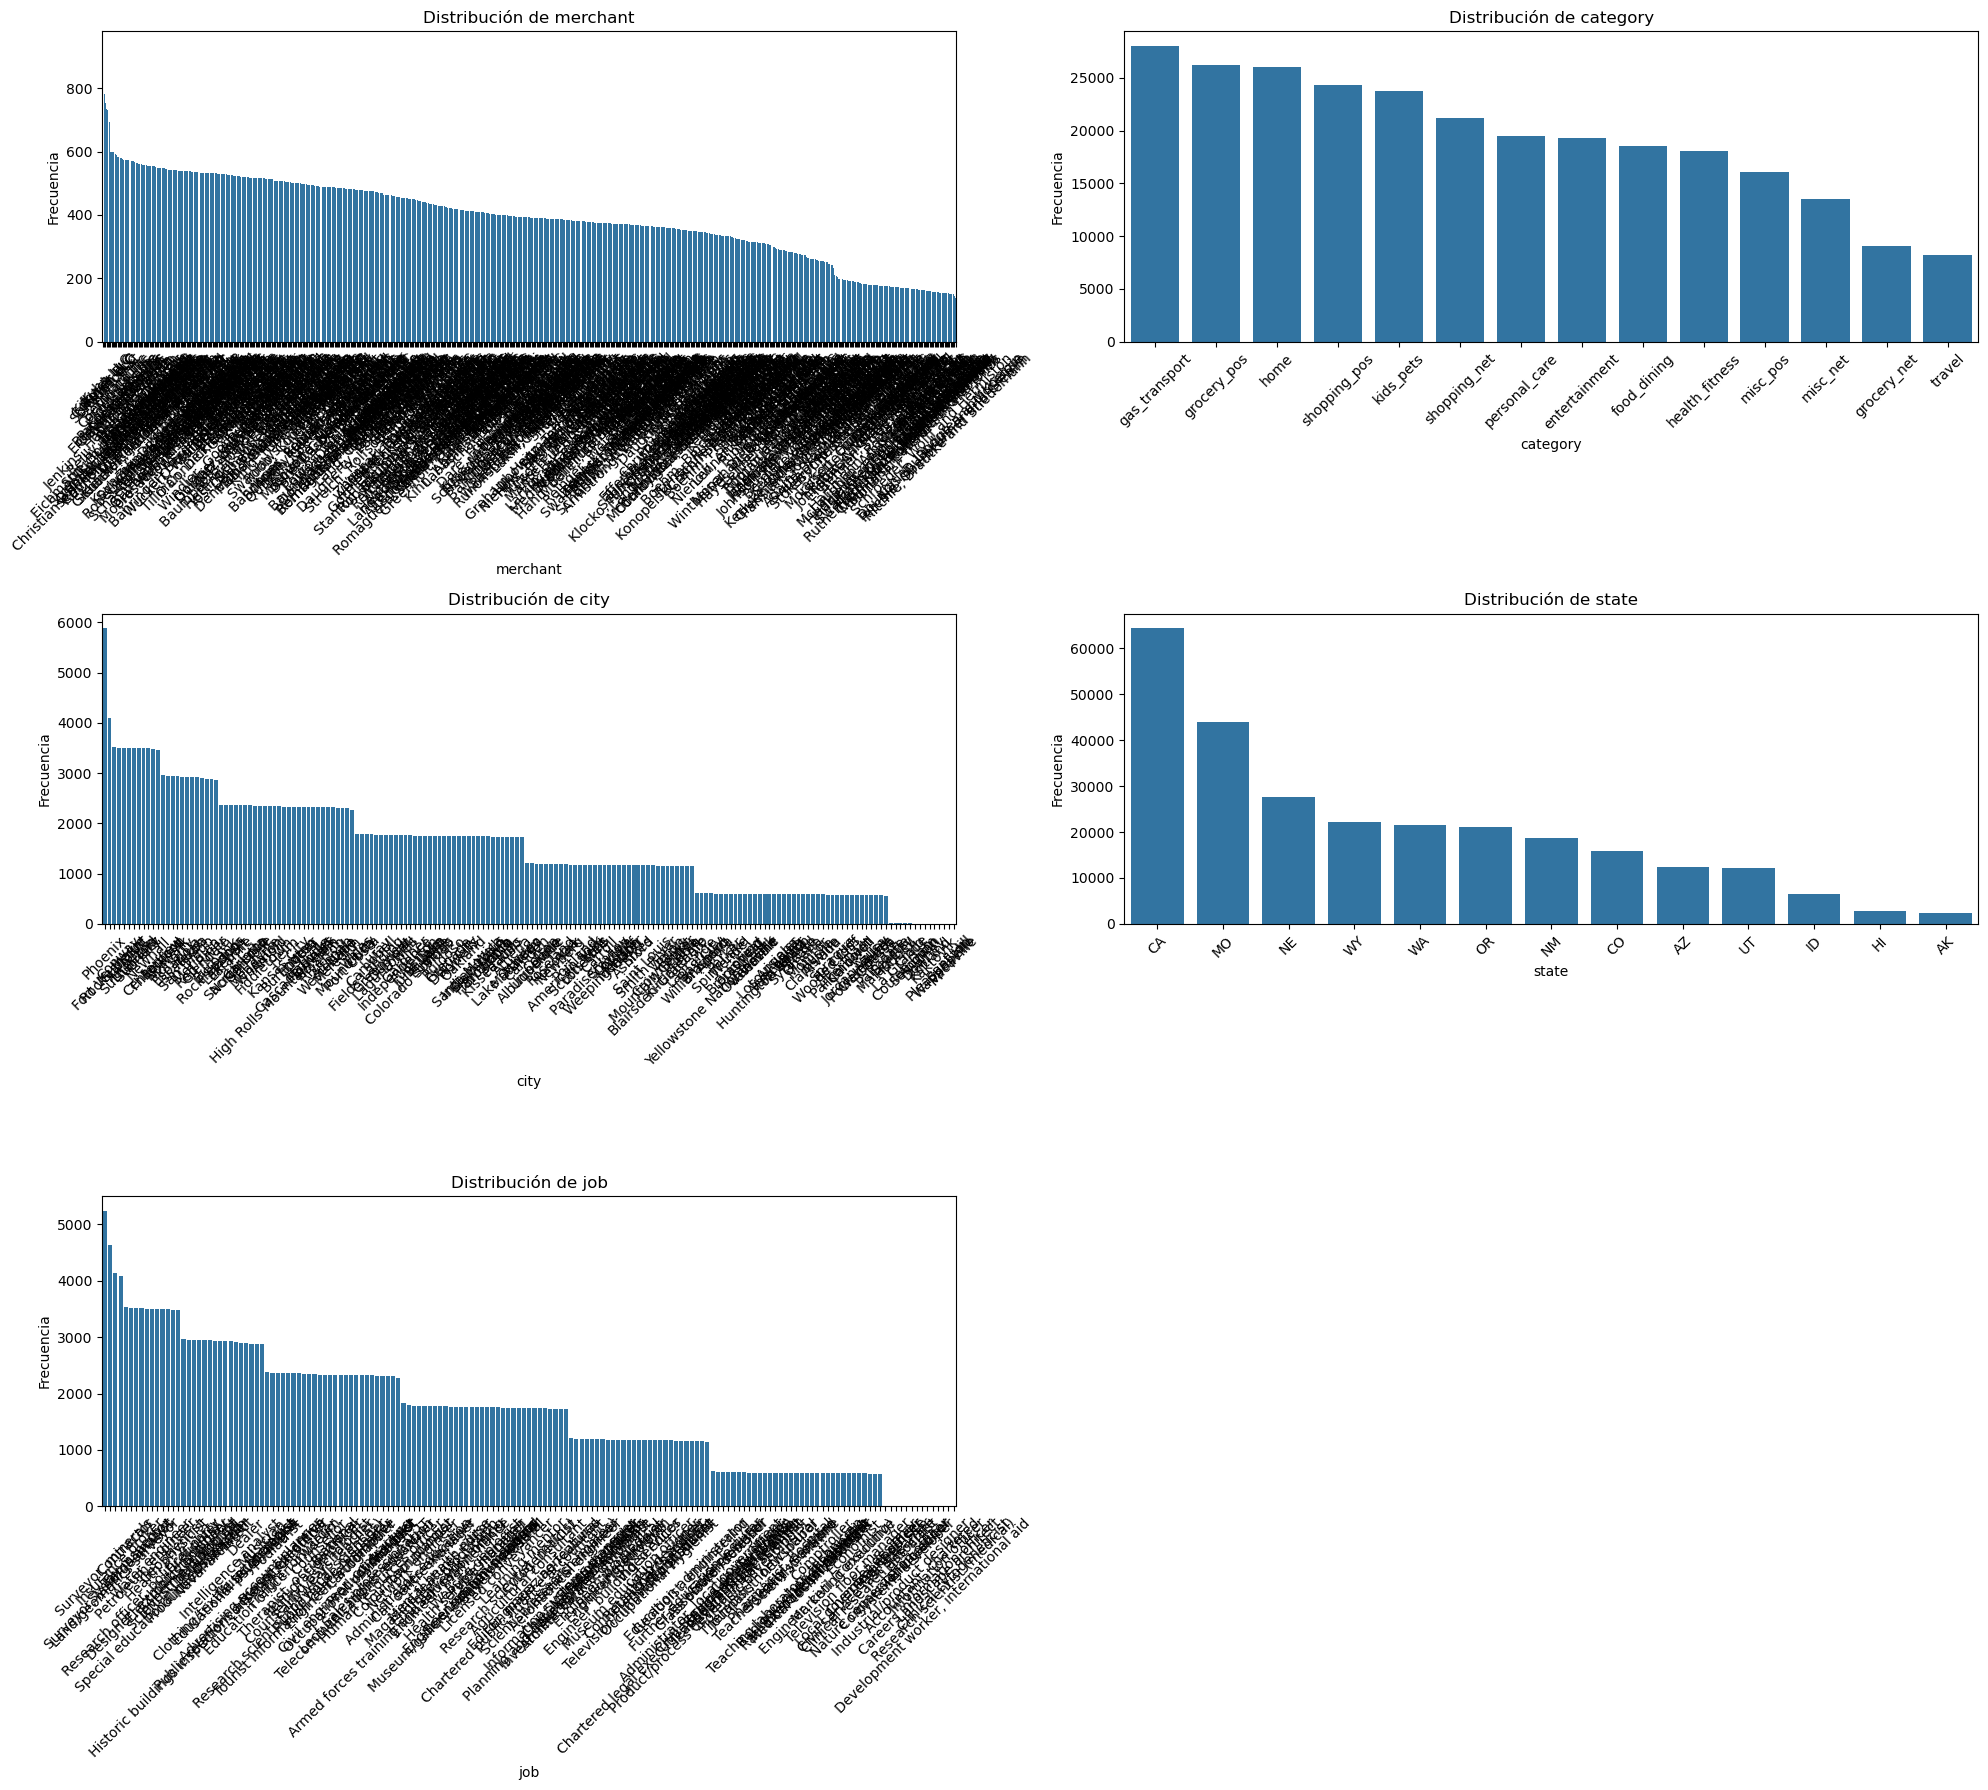

In [27]:
str_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns

nrows = len(str_cols) // 2 + len(str_cols) % 2
fig, axs = plt.subplots(nrows=nrows, ncols=2, figsize=(20, 6 * nrows))

axs = axs.flatten()

for i, col in enumerate(str_cols):
    sns.countplot(data=df_fraud, x=col, order=df_fraud[col].value_counts().index, ax=axs[i])
    axs[i].set_title(f'Distribución de {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frecuencia')
    axs[i].tick_params(axis='x', rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad

# Eliminar subplots vacíos si el número de columnas es impar
if len(str_cols) % 2 != 0:
    fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()

Como vemos en los gráficos, podemos ver a simple vista que hay mucha cardinalidad. Por lo que, nos estamos planteando si eliminarla o no.

**Correlaciones**

In [28]:
# 2. Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# 3. Isolate the correlations with the target variable 'is_fraud'
target_corr = corr_matrix['is_fraud'].sort_values(ascending=False)

print(target_corr)

is_fraud                 1.000000
amt                      0.114336
hour                     0.013657
age                      0.012556
lat                      0.008845
merch_lat                0.008335
day_of_week              0.002217
is_weekend              -0.000710
city_pop                -0.000778
long                    -0.004472
merch_long              -0.004503
dob                     -0.013175
trans_date_trans_time   -0.014825
month                   -0.017131
Name: is_fraud, dtype: float64


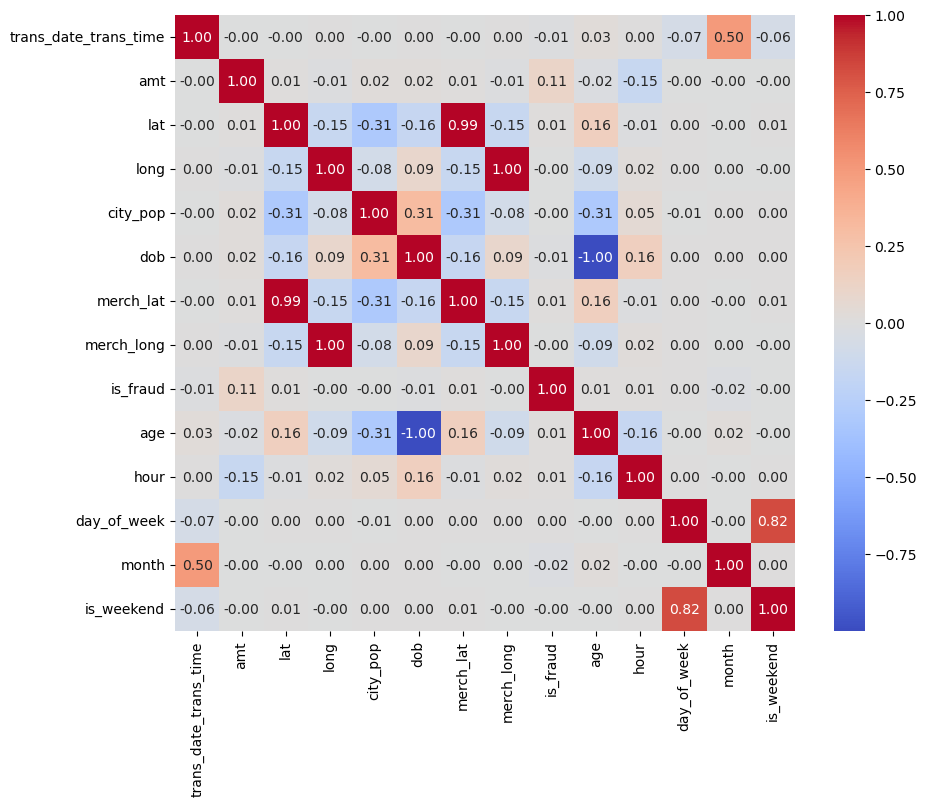

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

**Correlaciones Pearson & Spearman**

In [30]:
# Creamos un subset del dataframe original
df_corr = df[numeric_cols]

# 2. Calculamos las matrices de correlación
pearson_matrix = df_corr.corr(method='pearson')
spearman_matrix = df_corr.corr(method='spearman')


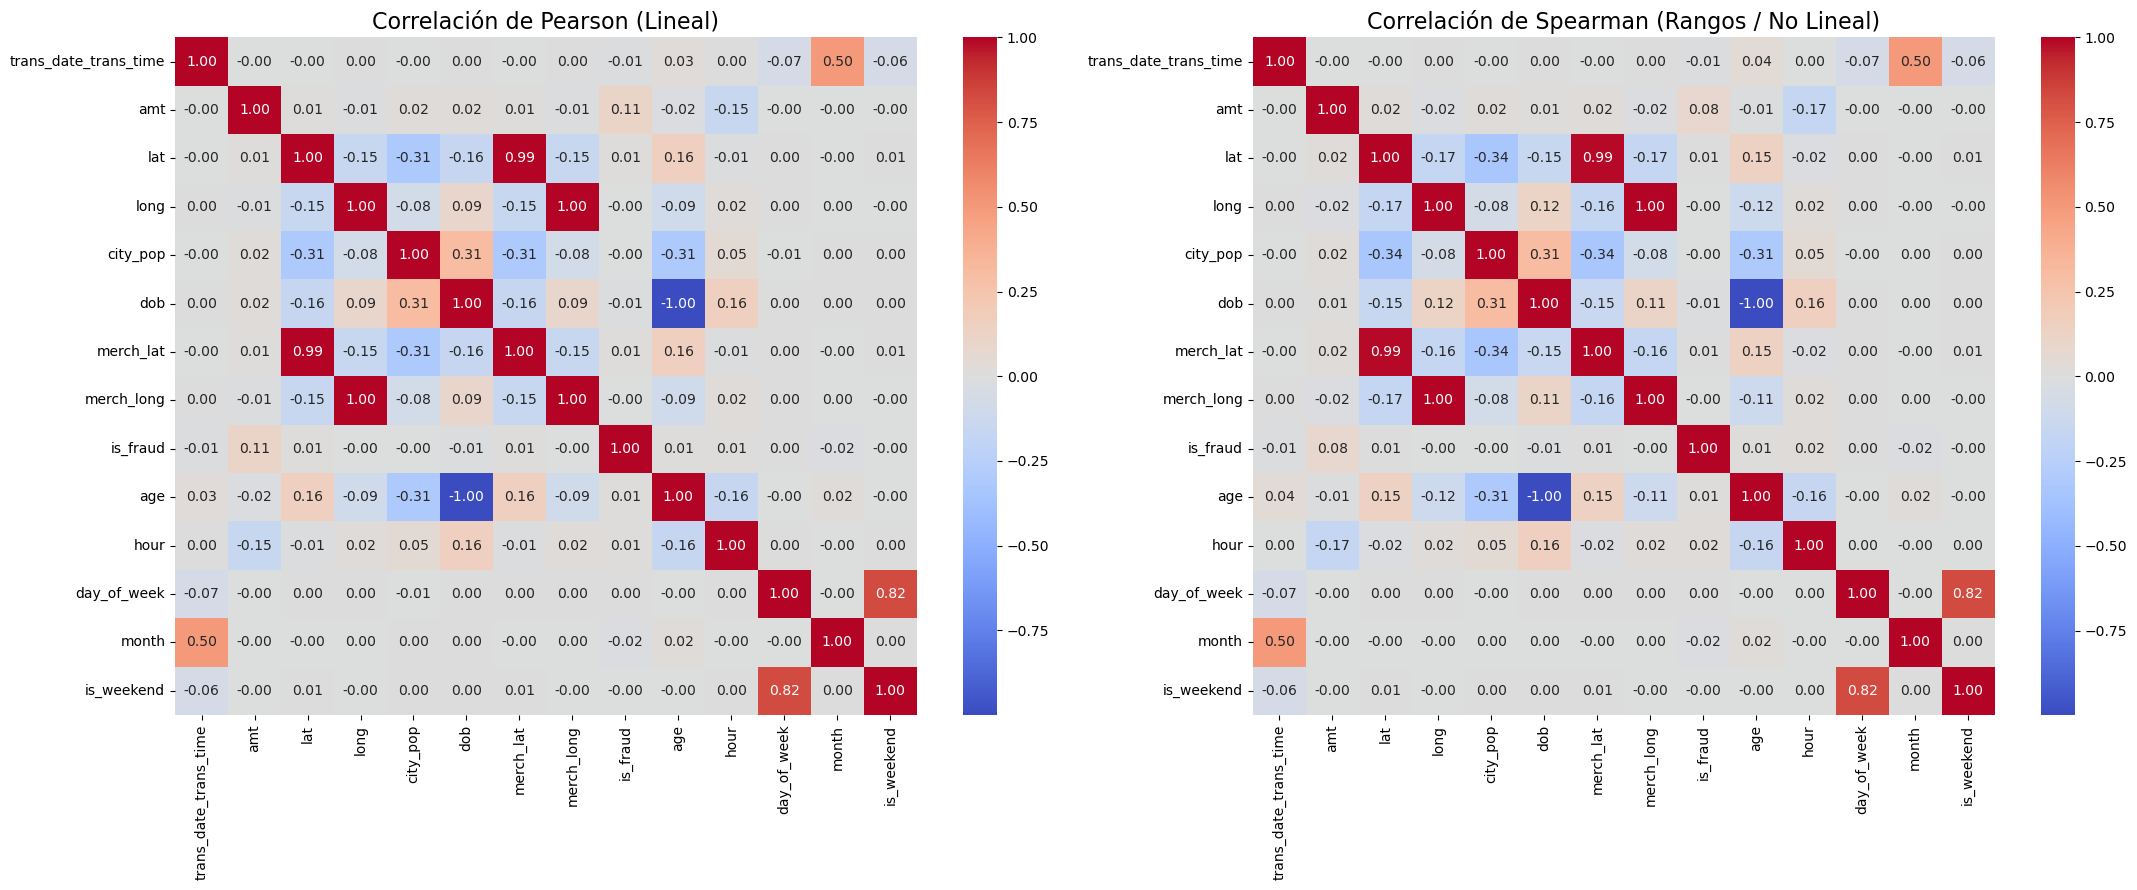

In [31]:
# 3. Configuramos la figura con dos subplots (uno al lado del otro)
fig, ax = plt.subplots(1, 2, figsize=(22, 9))

# Heatmap de Pearson
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0], cbar=True)
ax[0].set_title('Correlación de Pearson (Lineal)', fontsize=16)

# Heatmap de Spearman
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[1], cbar=True)
ax[1].set_title('Correlación de Spearman (Rangos / No Lineal)', fontsize=16)

plt.tight_layout()
plt.show()

In [32]:
# 4. Bonus: Mostrar solo la relación con 'is_fraud' ordenada
print("--- Correlación de Spearman con el Fraude (is_fraud) ---")
print(spearman_matrix['is_fraud'].sort_values(ascending=False))


--- Correlación de Spearman con el Fraude (is_fraud) ---
is_fraud                 1.000000
amt                      0.083914
hour                     0.022144
age                      0.012524
lat                      0.006963
merch_lat                0.006190
day_of_week              0.001855
city_pop                -0.000555
is_weekend              -0.000710
long                    -0.003499
merch_long              -0.003654
dob                     -0.013007
trans_date_trans_time   -0.014737
month                   -0.016700
Name: is_fraud, dtype: float64


In [33]:
# 4. Bonus: Mostrar solo la relación con 'is_fraud' ordenada
print("--- Correlación de Spearman con el Fraude (is_fraud) ---")
print(pearson_matrix['is_fraud'].sort_values(ascending=False))


--- Correlación de Spearman con el Fraude (is_fraud) ---
is_fraud                 1.000000
amt                      0.114336
hour                     0.013657
age                      0.012556
lat                      0.008845
merch_lat                0.008335
day_of_week              0.002217
is_weekend              -0.000710
city_pop                -0.000778
long                    -0.004472
merch_long              -0.004503
dob                     -0.013175
trans_date_trans_time   -0.014825
month                   -0.017131
Name: is_fraud, dtype: float64


**Info Mutua**

In [34]:
numeric_features = df.select_dtypes(include=['int','float64']).copy()
numeric_features.drop(columns = ['is_fraud'], inplace=True, errors='ignore')

target = df["is_fraud"] 

mi_numeric =mutual_info_classif(numeric_features, target, random_state=42)

mi_numeric_series = pd.Series(mi_numeric, index=numeric_features.columns).sort_values(ascending=False)

print("Info Mutua para numericas contra target: ")
print(mi_numeric_series)

Info Mutua para numericas contra target: 
is_weekend     0.018125
amt            0.015492
day_of_week    0.009117
hour           0.007831
month          0.006371
long           0.004117
lat            0.003969
city_pop       0.003866
age            0.002323
merch_lat      0.000279
merch_long     0.000039
dtype: float64


Decidimos eliminar las siguientes variables, que las eliminaremos más tarde, que son: lat, long, merch_lat, merch_long, city_pop, trans_date_trans_time y dob. Las fechas las eliminamos ya que las variables que hemos creado al principio los reemplaza.

**Variables Categóricas**

**chi-cuadrado**

In [35]:
resultados = []

print("--- Análisis de Chi-Cuadrado vs is_fraud ---")

for col in categoric_cols:
    # Creamos la tabla de contingencia (frecuencias cruzadas)
    contingency_table = pd.crosstab(df[col], df['is_fraud'])
    
    # Calculamos Chi2 y el p-valor
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    # Interpretación
    dependiente = "SÍ (Significativa)" if p < 0.05 else "NO (Independiente)"
    
    resultados.append({
        'Variable': col,
        'Chi2': round(chi2, 2),
        'p-valor': f"{p:.4e}", # Formato científico para p-valores muy pequeños
        'Relación con Fraude': dependiente
    })

# 2. Mostramos los resultados en una tabla limpia
df_chi = pd.DataFrame(resultados).sort_values(by='Chi2', ascending=False)
print(df_chi.to_string(index=False))



--- Análisis de Chi-Cuadrado vs is_fraud ---
Variable     Chi2     p-valor Relación con Fraude
    city 23476.21  0.0000e+00  SÍ (Significativa)
     job 21876.88  0.0000e+00  SÍ (Significativa)
merchant  1840.97 4.4057e-105  SÍ (Significativa)
category  1164.63 7.1808e-241  SÍ (Significativa)
   state    95.35  4.5107e-15  SÍ (Significativa)


Como vemos en el chi-cuadrado, vemos que todas las variables son significativas con el target.

**V de Cramer**

In [36]:
def cramers_v(contingency_table):
    """ Calcula el coeficiente V de Cramer para una tabla de contingencia. """
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

resultados_v = []

print("--- Análisis de Fuerza de Asociación (V de Cramer) ---")

for col in categoric_cols:
    # Creamos la tabla de contingencia
    contingency_table = pd.crosstab(df[col], df['is_fraud'])
    
    # Calculamos V de Cramer
    v = cramers_v(contingency_table)
    
    # Interpretación rápida de la fuerza
    if v > 0.5: fuerza = "Muy Fuerte"
    elif v > 0.3: fuerza = "Fuerte"
    elif v > 0.1: fuerza = "Moderada"
    else: fuerza = "Débil"
    
    resultados_v.append({
        'Variable': col,
        'Cramers V': round(v, 4),
        'Fuerza': fuerza
    })

# Mostramos resultados ordenados por fuerza
df_v = pd.DataFrame(resultados_v).sort_values(by='Cramers V', ascending=False)
print(df_v.to_string(index=False))

--- Análisis de Fuerza de Asociación (V de Cramer) ---
Variable  Cramers V   Fuerza
    city     0.2929 Moderada
     job     0.2827 Moderada
category     0.0651    Débil
merchant     0.0650    Débil
   state     0.0175    Débil


**ELIMINAMOS LAS SIGUIENTES COLUMNAS**

In [37]:
#Eliminamos 'state', todas las 'lat' y 'long' y las fechas, ya que no va a aportar mucho y solo va a generar ruido.
df.drop(columns=['state','trans_date_trans_time', 'dob', 'city_pop','lat','long','merch_lat','merch_long'],inplace=True)
df_test.drop(columns=['state','trans_date_trans_time', 'dob', 'city_pop','lat','long','merch_lat','merch_long'],inplace=True)

In [38]:
#Al final nos quedamos con estas columnas
df.info()

<class 'pandas.DataFrame'>
Index: 271685 entries, 179685 to 109523
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   merchant     271685 non-null  str    
 1   category     271685 non-null  str    
 2   amt          271685 non-null  float64
 3   city         271685 non-null  str    
 4   job          271685 non-null  str    
 5   is_fraud     271685 non-null  int64  
 6   age          271685 non-null  int64  
 7   hour         271685 non-null  int32  
 8   day_of_week  271685 non-null  int32  
 9   month        271685 non-null  int32  
 10  is_weekend   271685 non-null  int64  
dtypes: float64(1), int32(3), int64(3), str(4)
memory usage: 29.8 MB


In [39]:
#Vemos la dimensionalidad del dataset
df.shape 

(271685, 11)

In [40]:
# Seleccionamos solo las columnas de tipo objeto o categoría
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("--- Cardinalidad de Variables Categóricas ---")
for col in cat_cols:
    unique_count = df[col].nunique()
    print(f"{col:15} : {unique_count} valores únicos")

--- Cardinalidad de Variables Categóricas ---
merchant        : 693 valores únicos
category        : 14 valores únicos
city            : 176 valores únicos
job             : 163 valores únicos


C:\Users\Administrador\AppData\Local\Temp\ipykernel_11444\621772189.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


**Encoding**

1. Aplicamos Binary Encoding para aquellas variables que tienen mucha cardinalidad, con el fin de reducir las columnas lo máximo que se puedan y no otros tipos de encoding por tener demasiadas columnas.
2. Aplicamos el OneHotEncoding a 'category', ya que con 15 categorías el OneHotEncoding puede manejarlo.
3. Aplicamos el RobustScaler a todas las variables numéricas, excepto el 'amt' (porque ya le imputamos el logaritmo).

In [41]:
# 1. Asegúrate de que las columnas existen en tus DataFrames cargados
# (Si ya ejecutaste la ingeniería de variables antes, esto solo las selecciona)

columnas_que_queremos = df.columns.tolist()
columnas_que_queremos.remove('is_fraud')

# 2. REDEFINIR X_train y X_test con las nuevas columnas
# Es vital hacer esto justo antes del fit_transform
X_train = df[columnas_que_queremos]
X_test = df_test[columnas_que_queremos]

In [42]:
# Definir columnas
binary_features = ['merchant', 'city', 'job']
oh_features = ['category']
numeric_features = ['age', 'hour', 'day_of_week', 'month']

# Configurar el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('bin', BinaryEncoder(), binary_features),
        ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False), oh_features)
    ])

# AJUSTAR Y TRANSFORMAR
# fit_transform: aprende del entrenamiento y lo transforma
X_train_encoded = preprocessor.fit_transform(X_train)

# transform: aplica lo aprendido al test sin mirar sus datos
X_test_encoded = preprocessor.transform(X_test)

# Convertir a DataFrame con los nombres de las columnas
cols_names = preprocessor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_encoded, columns=cols_names)
X_test_final = pd.DataFrame(X_test_encoded, columns=cols_names)

In [43]:
# 1. Resetear índices (CRUCIAL)
# Al codificar, los índices de X cambian y si no reseteamos y_train/y_test, 
# Pandas no sabrá cómo pegarlos y te creará una tabla llena de errores (NaN).
y_train_res = y_train.reset_index(drop=True)
y_test_res = y_test.reset_index(drop=True)

# 2. Concatenar usando las versiones FINAL (Codificadas)
df_train_encoded = pd.concat([X_train_final, y_train_res], axis=1)
df_test_encoded = pd.concat([X_test_final, y_test_res], axis=1)

# 3. Guardar en CSV
# Asegúrate de que la carpeta "../data/" exista o te dará error
df_train_encoded.to_csv("../data/df_train.csv", index=False)
df_test_encoded.to_csv("../data/df_test.csv", index=False)

print("¡Archivos guardados correctamente!")

¡Archivos guardados correctamente!


In [44]:
df_train_encoded =pd.read_csv("../data/df_train.csv")
df_test_encoded = pd.read_csv("../data/df_test.csv")

In [46]:
df_test.shape , df.shape

((67922, 11), (271685, 11))

In [47]:
df_test_encoded.shape, df_train_encoded.shape

((67922, 45), (271685, 45))

In [48]:
df_test_encoded

,num__age,num__hour,num__day_of_week,num__month,bin__merchant_0,bin__merchant_1,bin__merchant_2,bin__merchant_3,bin__merchant_4,bin__merchant_5,...,oh__category_health_fitness,oh__category_home,oh__category_kids_pets,oh__category_misc_net,oh__category_misc_pos,oh__category_personal_care,oh__category_shopping_net,oh__category_shopping_pos,oh__category_travel,is_fraud
0,1.541667,-0.500000,0.25,-0.333333,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
1,-0.541667,0.750000,0.00,0.833333,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.750000,-0.750000,0.00,-0.666667,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
3,-0.291667,-0.916667,0.75,-0.666667,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-0.291667,0.666667,0.00,0.833333,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67917,-0.041667,-1.000000,-0.25,0.833333,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
67918,-0.708333,0.416667,0.25,0.833333,0.0,1.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
67919,0.166667,-0.750000,0.25,0.833333,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
67920,0.041667,0.083333,-0.50,-0.166667,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [49]:
df_train_encoded

,num__age,num__hour,num__day_of_week,num__month,bin__merchant_0,bin__merchant_1,bin__merchant_2,bin__merchant_3,bin__merchant_4,bin__merchant_5,...,oh__category_health_fitness,oh__category_home,oh__category_kids_pets,oh__category_misc_net,oh__category_misc_pos,oh__category_personal_care,oh__category_shopping_net,oh__category_shopping_pos,oh__category_travel,is_fraud
0,0.041667,-0.083333,0.50,-0.833333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.000000,0.583333,0.75,0.666667,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.541667,-0.333333,-0.75,-0.666667,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.791667,-0.666667,0.50,-0.500000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
4,0.958333,-0.750000,-0.75,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271680,0.125000,0.333333,-0.50,0.833333,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
271681,-0.541667,-0.416667,0.00,0.666667,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
271682,1.041667,-0.750000,-0.75,0.333333,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
271683,-0.750000,0.250000,0.25,0.500000,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
